7


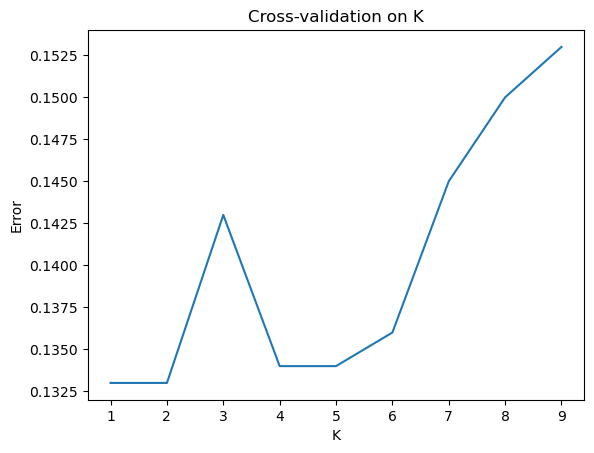

0.8668193324106703
[[ 938    1    5    1    1    8   12    2    1   11]
 [   0 1126    0    2    0    2    2    1    2    0]
 [  18   39  872   10    5    8   13   49   15    3]
 [   1    7   23  835    0   81    7   17   23   16]
 [   0   20    1    0  791    1   13   17    1  138]
 [  15   13    2   48    9  721   25    9   22   28]
 [  21    5    3    1   13   11  897    0    3    4]
 [   1   36    5    2   14    3    0  913    1   53]
 [  24    8   32   28   20   65   11   22  713   51]
 [   6    3    2   11   43    5    4   48    3  884]]


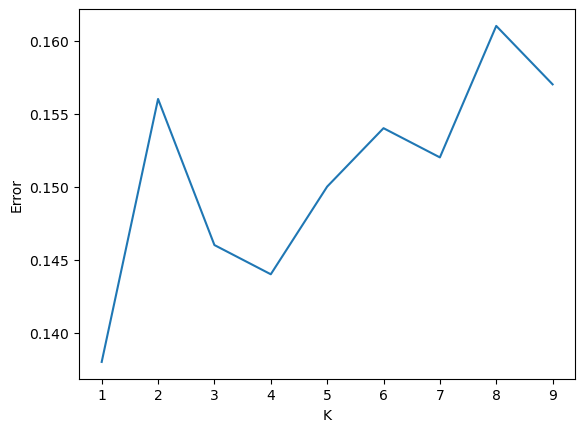

Test set score:0.849600


In [1]:
import operator

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier


def myknn(sample, tr_feats, tr_label, k):
    rowSize = tr_feats.shape[0]     # rowSize equals number of training data
    # repeat sample the number of rowSize times and compute the difference with training data
    diff = np.tile(sample, (rowSize, 1)) - tr_feats
    sqrDiff = diff ** 2     # compute the square of the difference
    sqrDiffSum = sqrDiff.sum(axis=1)        # sum the squared difference for comparison to each training data
    distances = sqrDiffSum ** 0.5       # calculate Euclidean distance
    sortDistance = distances.argsort()  # sort distance  (from lowest to highest)

    count = {}
    # calculate each class's frequency in the nearest k training data
    for i in range(k):
        vote = tr_label[sortDistance[i]]        # obtain the i th nearest sample's label in the training set
        count[vote] = count.get(vote, 0) + 1    # update the count of the i th nearest sample's label

    # sort the frequency of each class  (from highest to lowest)
    sortCount = sorted(count.items(), key=operator.itemgetter(1), reverse=True)
    # return predicted class
    return sortCount[0][0]


def select_best_k(trainval_feats, trainval_label, max_k):
    folds = 5

    # create a dict with keys from 1 to k and all values as empty list
    errors_of_k = {}
    for k in range(1, max_k + 1):
        errors_of_k[k] = []

    X_folds = np.vsplit(trainval_feats, folds)      # vertically split the data to 5 folds
    y_folds = np.hsplit(trainval_label, folds)      # horizontally split the data to 5 folds

    # iterate all folds
    for i in range(folds):
        # let the i th fold being validation set
        tv_feats = X_folds[i]
        tv_label = y_folds[i]
        # stack folds except i th fold to obtain the training set
        tr_feats = np.vstack(X_folds[:i] + X_folds[i + 1:])
        tr_label = np.hstack(y_folds[:i] + y_folds[i + 1:])

        # iterate all possible ks
        for k in range(1, max_k + 1):
            val_pred = []
            # iterate all samples in the validation set record the prediction in val_pred
            for i in range(tv_feats.shape[0]):
                pred = myknn(tv_feats[i], tr_feats, tr_label, k)    # obtain prediction with our myknn function
                val_pred.append(pred)                               # record the prediction
            # compute the error rate by comparing the prediction with the ground truth label
            error_rates = 1 - accuracy_score(tv_label, val_pred)
            # record the error rate in the dict errors_of_k
            errors_of_k[k].append(error_rates)

    '''
        Plot error rates-k figure
    '''
    # define k_range from 1 to k, also the X-axis in the figure to be displayed
    k_range = np.arange(1, max_k + 1)
    # compute the averaged error rate of 5 folds for all possible ks
    errors_mean = np.array([np.mean(v) for k, v in sorted(errors_of_k.items())])

    plt.plot(k_range, errors_mean)          # plot the error rate visualisation for all possible ks
    plt.title('Cross-validation on K')      # assign title
    plt.xlabel('K')         # assign label for X axis
    plt.ylabel('Error')     # assign label for Y axis
    plt.show()              # display figure


def eval_myknn(te_feats, te_label, tr_feats, tr_label, best_k):
    test_pred = []
    # iterate all sample in the testing set (te_feats) and record the prediction in test_pred
    for i in range(te_feats.shape[0]):
        pred = myknn(te_feats[i], tr_feats, tr_label, best_k)   # obtain prediction with our myknn function
        test_pred.append(pred)                                  # record the predcition
    print(f1_score(te_label, test_pred, average='macro'))       # print f1 score
    print(confusion_matrix(te_label, test_pred))                # print confusion matrix


def sklearn_knn_cv(tr_feats, tr_label, max_k):
    '''
        cross validation on K
    '''
    k_error = []
    folds = 5
    # define k_range from 1 to k, also the X-axis in the figure to be displayed
    k_range = np.arange(1, max_k + 1)
    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k)       # define a KNN classifier with k
        scores = cross_val_score(knn, tr_feats, tr_label, cv=folds, scoring='accuracy')  # obtain cross validation score
        k_error.append(1 - scores.mean())   # record the averaged error rate of k

    plt.plot(k_range, k_error)  # plot the error rate visualisation for all possible ks
    plt.xlabel('K')             # assign label for X axis
    plt.ylabel('Error')         # assign label for Y axis
    plt.show()                  # display figure


def sklearn_knn_test(te_feats, te_label, tr_feats, tr_label, best_k):
    knn = KNeighborsClassifier(n_neighbors=best_k)  # define a KNN classifier with best_k
    knn.fit(tr_feats, tr_label)                     # pass training data and labels to the KNN classifier

    acc_mean = knn.score(te_feats, te_label)        # compute the accuracy
    print('Test set score:{:2f}'.format(acc_mean))


def main():
    X, y = fetch_openml('mnist_784', data_home='./', return_X_y=True)  # fetch data using fetch_openml function
    X = X / 255.  # Normalization
    X = X.values  # Extract X values (from DataFrame to Numpy array)
    y = y.values  # Extract Y values (from DataFrame to Numpy array)

    # using the first 1000 sample for training
    tr_feats = X[:1000]
    tr_label = y[:1000]
    # using the last 10000 sample for tesing
    te_feats = X[-10000:]
    te_label = y[-10000:]

    # set max_k to 9
    max_k = 9

    '''
        task 1: Implement own instance based learning technique (KNN) 
    '''
    k = 5
    sample = X[60000]
    pred = myknn(sample, tr_feats, tr_label, k)
    print(pred)

    '''
        task 2: Implement cross validation on the training data for selecting the best k 
    '''

    select_best_k(tr_feats, tr_label, max_k)

    '''
        task 3: - classify the test images
                    - calculate F1 scores for each digit
                    - compute the confusion matrix 

    '''
    best_k = 2
    eval_myknn(te_feats, te_label, tr_feats, tr_label, best_k)

    '''
        task4: use functions from sklearn library 
    '''

    sklearn_knn_cv(tr_feats, tr_label, max_k)
    sklearn_knn_test(te_feats, te_label, tr_feats, tr_label, best_k=2)


if __name__ == "__main__":
    main()